In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import curve_fit
import itertools
import pandas as pd
import scipy.cluster.hierarchy as sch
import scipy.spatial.distance as ssd

def _to_str_list(mat_field):
    """
    Convert MATLAB cell/char arrays to a flat Python list of strings.
    Handles cases like: cell array of strings, char matrix, or object arrays.
    """
    x = np.squeeze(mat_field)
    if x.dtype.kind in ("U", "S"):  # already a (numpy) string array
        # char matrix (n x m) -> single string, else array of strings
        if x.ndim == 1:
            return [str(s) for s in x.tolist()]
        else:
            return ["".join(row).strip() for row in x.tolist()]
    # likely an object array (cell array)
    out = []
    for elem in np.ravel(x):
        s = elem
        # char arrays come as ndim>=2 with dtype 'U'/'S'
        if isinstance(elem, np.ndarray) and elem.dtype.kind in ("U", "S"):
            s = "".join(np.atleast_1d(elem).tolist()).strip()
        elif isinstance(elem, np.ndarray) and elem.dtype.kind in ("i", "f"):
            s = str(elem.item()) if elem.size == 1 else "".join(map(str, elem.tolist()))
        else:
            s = str(elem)
        out.append(s)
    return out

In [3]:
directory = "/mnt/hcleroy/PostDoc2/octopus_smelling/data/matlab_files/v2"
mat_path = directory+"/20260120_HiPlexResults.mat"
# --- Load .mat ---
md = loadmat(mat_path, squeeze_me=True, struct_as_record=False)
if "binaryTable_Stack" not in md or "CRnames" not in md:
    raise KeyError("Expected fields 'binaryTable_Stack' and 'CRnames' in the .mat file.")

A = np.array(md["binaryTable_Stack"]).astype(bool).astype(int)  # shape: (n_receptors, n_cells)
CRnames = np.array(_to_str_list(md["CRnames"]))
nR, nC = A.shape


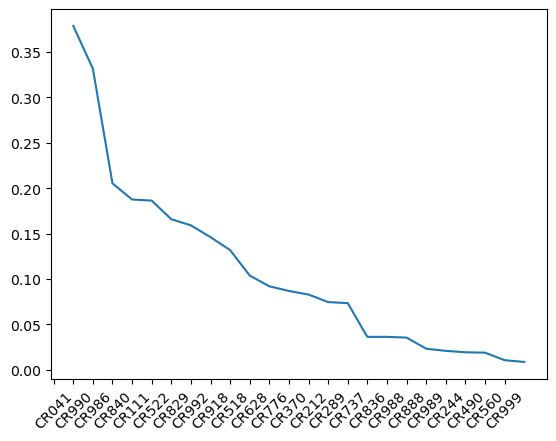

In [4]:
# ---------------------------------------------------------
# 1. Plot the probability expression of each individual gene
# ---------------------------------------------------------
# Calculate the mean across the columns (cells) for each row (gene)
prob_expr = A.mean(axis=1)
id_sort = np.argsort(-prob_expr)

plt.plot(range(1,25),prob_expr[id_sort])
plt.xticks(np.arange(nR), CRnames[id_sort],rotation=45)
plt.show()

In [5]:
# ---------------------------------------------------------
# 2. Find the first few probable gene patterns
# ---------------------------------------------------------
# Transpose A so that each row is a cell and each column is a gene
# Then convert it into a pandas DataFrame for easy frequency counting
df = pd.DataFrame(A.T)

# Count the occurrences of each unique pattern (row)
pattern_counts = df.value_counts().reset_index(name='count')

# Calculate the probability of each pattern
pattern_counts['probability'] = pattern_counts['count'] / A.shape[1]

# Display the top 10 most frequent gene patterns
print("Top 10 most probable gene patterns:")
top_10_patterns = pattern_counts.head(10)
print(top_10_patterns.to_string(index=False))

Top 10 most probable gene patterns:
 0  1  2  3  4  5  6  7  8  9  10  11  12  13  14  15  16  17  18  19  20  21  22  23  count  probability
 0  0  0  0  0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0    502     0.198184
 0  0  1  0  0  0  0  0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0    222     0.087643
 0  0  0  1  0  0  1  0  0  0   0   0   1   0   1   0   0   0   0   0   0   0   0   0    106     0.041848
 0  0  0  0  0  0  1  0  0  0   0   0   1   0   0   0   0   0   0   0   0   0   0   0    101     0.039874
 0  0  0  0  0  0  1  0  0  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0     60     0.023687
 0  0  0  0  0  0  0  0  0  0   0   0   1   0   0   0   0   0   0   0   0   0   0   0     56     0.022108
 0  0  0  0  0  0  1  0  0  0   0   0   1   0   1   0   0   0   0   0   0   0   0   0     54     0.021319
 0  0  1  0  0  0  0  0  0  0   0   0   1   0   0   0   0   0   0   0   0   0   0   0     40     0.015792
 0  0  0  

In [6]:
# 1. Pairwise Correlation Matrix (24x24)
# Values near 0 indicate independence between that pair of genes.
corr_matrix = np.corrcoef(A)

# 2. Observed vs Expected Co-expression (Example for Gene 0 and Gene 1)
gene_A_idx, gene_B_idx = 0, 1

# Expected joint probability if strictly independent
expected_joint_prob = prob_expr[gene_A_idx] * prob_expr[gene_B_idx]

# Actual observed joint probability
observed_joint_prob = np.mean((A[gene_A_idx, :] == 1) & (A[gene_B_idx, :] == 1))

print(f"Expected: {expected_joint_prob:.4f}, Observed: {observed_joint_prob:.4f}")

Expected: 0.0024, Observed: 0.0142


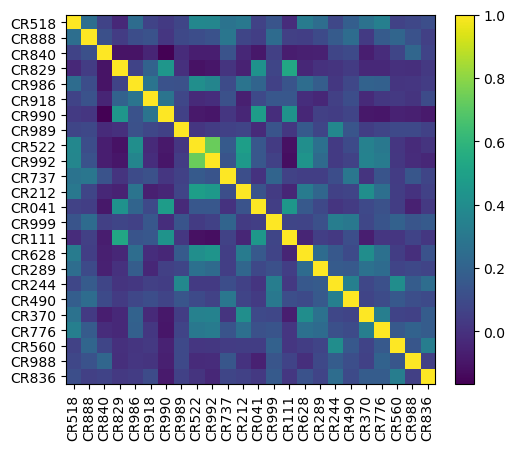

In [7]:
im = plt.imshow(corr_matrix)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(nR), CRnames, rotation=90)
plt.yticks(np.arange(nR), CRnames)
plt.show()

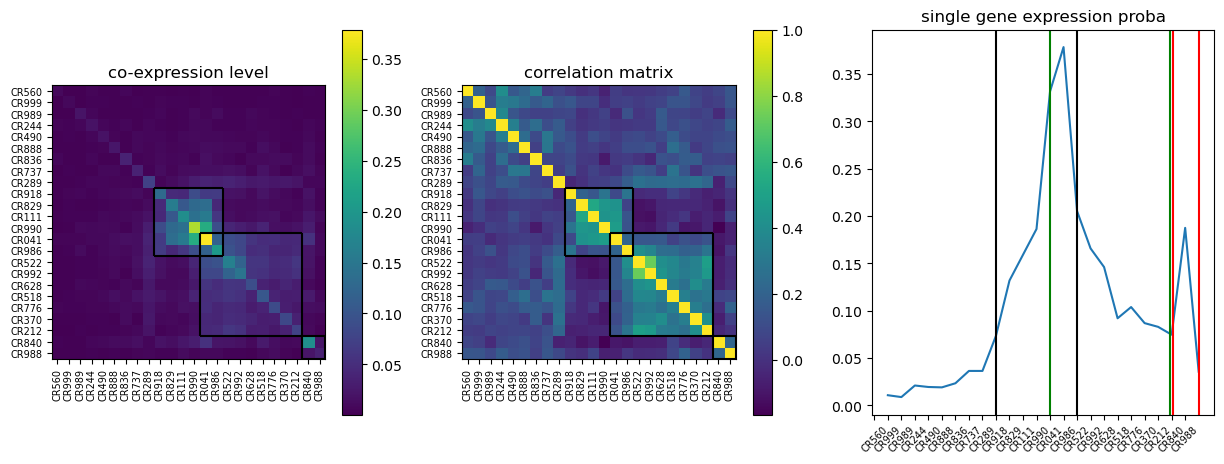

In [81]:
fig,ax = plt.subplots(ncols=3,figsize=(15,5))

############################GROUP BY CORRELATION######################
# Force strict symmetry to fix floating-point errors
corr_matrix = (corr_matrix + corr_matrix.T) / 2
#############################LOOK AT THE COOEXPRESSION PROBA###############""
# Compute individual probabilities
prob_expr = A.mean(axis=1)
num_cells = A.shape[1]
co_expr = (A @ A.T) / num_cells


# 1. Convert correlation to a distance metric
#dist_matrix = 1 - corr_matrix
dist_matrix = max(co_expr.flatten()) - co_expr
np.fill_diagonal(dist_matrix, 0)
# Now squareform will accept it
condensed_dist = ssd.squareform(dist_matrix)
# 2. Compute hierarchical clustering
linkage_matrix = sch.linkage(condensed_dist, method='average')
# 3. Get the new ordered indices
reordered_idx = sch.leaves_list(linkage_matrix)


reordered_idx[14], reordered_idx[19] = reordered_idx[19], reordered_idx[14]
reordered_idx[15], reordered_idx[20] = reordered_idx[20], reordered_idx[15]
reordered_idx[16], reordered_idx[21] = reordered_idx[21], reordered_idx[16]
#reordered_idx[11], reordered_idx[8] = reordered_idx[8], reordered_idx[11]

####################### PLOT ############################
im = ax[1].imshow(corr_matrix[reordered_idx, :][:, reordered_idx])
cbar = plt.colorbar(im)
ax[1].set_xticks(np.arange(nR), CRnames[reordered_idx], rotation=90,fontsize=7)
ax[1].set_yticks(np.arange(nR), CRnames[reordered_idx],fontsize=7)
ax[1].set_title('correlation matrix')


# Color plot
im2 = ax[0].imshow(co_expr[reordered_idx, :][:, reordered_idx])
cbar = plt.colorbar(im2)
ax[0].set_xticks(np.arange(nR), CRnames[reordered_idx], rotation=90,fontsize=7)
ax[0].set_yticks(np.arange(nR), CRnames[reordered_idx],fontsize=7)
ax[0].set_title('co-expression level')

ax[2].plot(range(1,25),prob_expr[reordered_idx])
ax[2].set_xticks(np.arange(nR), CRnames[reordered_idx],rotation=45,fontsize=7)
ax[2].set_title('single gene expression proba')

starts = np.array([8.,12.,21.])
ends = np.array([14.,21,23.])
starts+=0.5
ends+=0.5
for i in range(2):
    for s,e in zip(starts,ends):
        ax[i].hlines([s,e],s,e,color='black')
        ax[i].vlines([s,e],s,e,color='black')
ax[2].axvline([9.],color='black')
ax[2].axvline([15.],color='black')
ax[2].axvline([13.],color='green')
ax[2].axvline([22.-0.1],color='green')
ax[2].axvline([22.+0.1],color='red')
ax[2].axvline([24.],color='red')

plt.show()

In [132]:
starts = np.array([0.,9.,16.,22.])
ends = np.array([9,16.,22,24.])
labels = [i for i,(start,end) in enumerate(zip(starts,ends)) for _ in range(int(start),int(end))]
print(labels.__len__())

24


/tmp/ipykernel_9472/3636884788.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', 4)


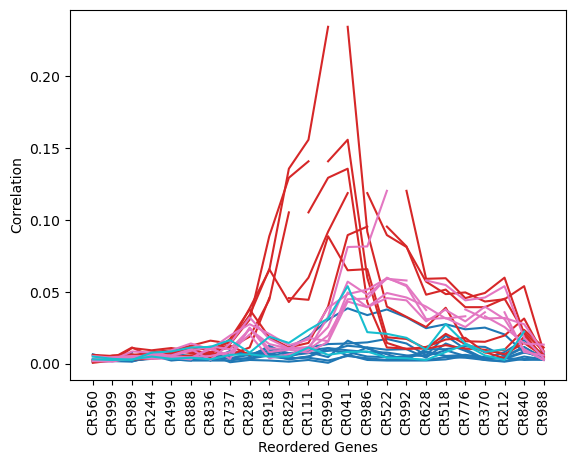

In [135]:


# --- 2. Line plots with diagonal removed ---
# Copy matrix and set diagonal to NaN so it doesn't plot
matrix_no_diag = co_expr[reordered_idx, :][:, reordered_idx].copy()
np.fill_diagonal(matrix_no_diag, np.nan)

colors = plt.cm.get_cmap('tab10', 4)

for i in range(len(matrix_no_diag)):
    plt.plot(matrix_no_diag[i], color=colors(int(labels[i])),label=labels[i])
plt.xlabel('Reordered Genes')
plt.ylabel('Correlation')
plt.xticks(np.arange(nR), CRnames[reordered_idx], rotation=90)
#plt.legend()
plt.show()

In [117]:
colors = plt.cm.get_cmap('tab10', k)
print(colors(2))
print(colors(3))

(np.float64(0.09019607843137255), np.float64(0.7450980392156863), np.float64(0.8117647058823529), np.float64(1.0))
(np.float64(0.09019607843137255), np.float64(0.7450980392156863), np.float64(0.8117647058823529), np.float64(1.0))


/tmp/ipykernel_9472/3720320834.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', k)
